# 问题三 求解讲解：算力约束下的多维资源联合优化与结构性转移

**任务拆解**：

1. 建立总成本模型并在预算约束下求解最优 $(N,D,Q)$（领域配比 $\bm p$ 可作联立决策变量，也可由前两问结果确定，但须说明理由）；
2. 讨论**成本函数选择**对最优解的影响（附录 B 给出三型可选）；
3. 分析预算跨越不同量级时是否出现**结构性转移**，并给出明确的数学定义与识别方法；
4. $L_{\text{ctx}}$ 外生给定、其可行取值须依据 C7，并须解析给出 $L_{\text{crit}}=6/\eta$ 后在其可行取值上完成敏感性分析。

**成本模型严格按赛题公式**：

$$C=\underbrace{6ND}_{\text{基础训练}}+\underbrace{D[g(Q)-g(Q_0)]_+}_{\text{质量提升}}+\underbrace{\eta NDL_{\text{ctx}}}_{\text{长文本注意力}},\qquad \eta=2\times10^{-4}$$

> 提醒：这里刻意**不做任何简化**（尤其不把质量成本写成与 $D$ 无关），因为简化会改变最优解的结构。

> **运行说明**
> - 本 notebook 放在 `求解/问题X/` 目录下，请在该目录下打开；`_common.py` 会自动定位附件目录、输出目录与字体。
> - 依赖：`numpy`、`pandas`、`scipy`、`matplotlib`（无需 GPU）。
> - 单元已带上次真实运行的输出，直接看即可；想复现就从上到下 Run All。
> - 结果 CSV 写入 `结果/`，图片写入 `图片/`。

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
# 让本 notebook 能 import 到 求解/_common.py（notebook 位于 求解/问题X/ 下）
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from _common import *   # noqa: F401,F403

# 在 Jupyter 中运行时，让 save_fig 除保存文件外也把图片内联显示出来。
# 注意必须改 _common 模块的属性：脚本头部还会再执行一次 `from _common import *`，
# 只改本地名字会被覆盖。
try:
    from IPython.display import display as _ipy_display, Image as _ipy_Image
    import _common as _cm
    _orig_save_fig = _cm.save_fig
    def save_fig(fig, name_cn, dpi=300):
        _orig_save_fig(fig, name_cn, dpi)
        try:
            _ipy_display(_ipy_Image(filename=os.path.join(_cm.FIG_DIR, name_cn + '.png')))
        except Exception:
            pass
    _cm.save_fig = save_fig
except Exception:
    pass   # 非 Jupyter 环境（直接跑脚本）不需要内联显示

print('附件目录:', DATA_DIR)
print('结果目录:', OUT_DIR)
print('图片目录:', FIG_DIR)


附件目录: C:\Users\qq190\Desktop\第二十三届中国研究生数学建模竞赛 - 中文题目\中文题目\F题\real_attachments
结果目录: C:\Users\qq190\Desktop\研赛（华为杯）f题\研赛（华为杯）_2026-09-23_08-27-48\求解\问题三\结果
图片目录: C:\Users\qq190\Desktop\研赛（华为杯）f题\研赛（华为杯）_2026-09-23_08-27-48\求解\问题三\图片


### 准备：模块头与公共工具函数

这一段是脚本自己的模块头（导入 + `save_csv_safe` 等公共小工具）。notebook 环境下 `__file__` 不存在，
因此原来那行 `sys.path.insert(... __file__ ...)` 已在上面的第 1 个单元用等价方式取代。

> 小技巧：`save_csv_safe` 会在目标 CSV 被 Excel 等程序占用时自动改存为 `*_new.csv`，保证整条流水线不中断。

In [2]:
# -*- coding: utf-8 -*-
"""
问题三：算力约束下的多维资源联合优化与结构性转移
输入：问题二广义标度律参数 L(N,D,Q)=E+A/N^a+B/D^b+C(1-Q)^g；
      问题一的质量基线 Q0 与配比修正 M(p)；附件 C7 的上下文长度可行取值。
成本（严格按赛题附录 B 与正文公式）：
      C_total = C_train + C_Q + C_attn
              = 6 N D + D * [g(Q) - g(Q0)]_+ + eta * N * D * L_ctx,  eta = 2e-4
      g(Q) 取附录 B 三型（指数型 1e7*exp(6Q)、幂函数型 5e9*Q^4、对数渐进型 2e9*ln(1+10Q)）
临界上下文长度：注意力开销 = 基础训练开销 <=> eta*N*D*L = 6*N*D <=> L_crit = 6/eta = 30000
方法：三档预算联合优化（SLSQP，对数参数化）；预算扫略 + 结构性转移识别；L_ctx 敏感性。
输出：图片到 图片/，结果 CSV 到 结果/。
"""
import sys, os, json
# （sys.path 已在第 1 个代码单元中设置，notebook 里不需要 __file__）
from _common import *   # noqa: F401,F403
from scipy.optimize import minimize

DATA = data_path

def save_csv_safe(df, name_cn):
    p = os.path.join(OUT_DIR, name_cn)
    try:
        df.to_csv(p, index=False, encoding='utf-8-sig')
    except PermissionError:
        alt = p.replace('.csv', '_new.csv')
        df.to_csv(alt, index=False, encoding='utf-8-sig')
        print('  ! %s 被占用，已改存为 %s' % (name_cn, os.path.basename(alt)))


## 第 0 步：读取前两问的输出（跨问耦合）

本问**不重新读原始附件**，而是直接读问题一、问题二产出的接口文件：

- `求解/广义标度律参数.csv` → $\{E,A,\alpha,B,\beta,C,\gamma\}$，作为优化目标；
- `求解/问题一_关键量.json` → 全局平均质量与参考语料配比加权质量；
- `求解/17域质量映射.csv` + `train_mixture_1m.csv` → 用来算**基线质量** $Q_0=\sum_k\bar p_kQ_k$。

关于 $Q_0$：直接取全量样本均值会被抽样设计影响（github 域占比过高），因此本文用**参考语料配比加权**的方式定义基线（$Q_0=0.3642$，对照的样本均值为 0.3263）。

In [3]:
# ============ 0. 读取前两问输出 ============
params = pd.read_csv(shared_path('广义标度律参数.csv'), index_col='param')['value']
E, A, alpha, B, beta, Cq, gamma = (params['E'], params['A'], params['alpha'],
                                   params['B'], params['beta'], params['C'], params['gamma'])

with open(shared_path('问题一_关键量.json'), encoding='utf-8') as fh:
    k1 = json.load(fh)
Q0_sample = float(k1['Q0_global_mean'])

mix_map = pd.read_csv(shared_path('17域质量映射.csv'))
ref_mix = pd.read_csv(data_path('train_mixture_1m.csv'))
ref_cols = [c for c in ref_mix if c.startswith('train_the_pile_')]
ref_p = ref_mix[ref_cols].mean().to_numpy(float)
ref_dom = [c.replace('train_the_pile_', '') for c in ref_cols]
qmap = mix_map.set_index('mixture_domain')['quality_Q']
q_vec = np.array([float(qmap.get(d, Q0_sample)) for d in ref_dom])
Q0 = float(ref_p @ q_vec)        # 基线质量 = 参考语料配比加权平均质量
print('=== 0. 质量基线与模型参数（来自问题一、二）===')
print('  参考语料配比加权基线质量 Q0 = %.4f（全量样本均值 %.4f）' % (Q0, Q0_sample))
print('  标度律：E=%.4f A=%.4f alpha=%.4f B=%.4f beta=%.4f C=%.4f gamma=%.4f'
      % (E, A, alpha, B, beta, Cq, gamma))

def loss(N_abs, D_abs, Q, M_p=0.0):
    """验证损失：参数以 B 为单位代入问题二标度律，M_p 为配比项修正。"""
    return (E + A * (N_abs / 1e9) ** (-alpha) + B * (D_abs / 1e9) ** (-beta)
            + Cq * (1 - Q) ** gamma + M_p)


=== 0. 质量基线与模型参数（来自问题一、二）===
  参考语料配比加权基线质量 Q0 = 0.3642（全量样本均值 0.3263）
  标度律：E=1.6558 A=0.3808 alpha=0.3266 B=1.2515 beta=0.2767 C=0.3544 gamma=0.9779


## 第 1 步：附录 B 规定的三型质量成本函数

$$g_{\text{指数}}(Q)=10^{7}e^{6.0Q},\quad g_{\text{幂函数}}(Q)=5\times10^{9}Q^{4.0},\quad g_{\text{对数渐进}}(Q)=2\times10^{9}\ln(1+10.0Q)$$

质量提升的算力代价为 $C_Q=D\,[g(Q)-g(Q_0)]_+$。**注意它与训练 token 数 $D$ 成正比**——含义是"对整份语料做质量处理"，数据量越大、达到同样质量的总开销越高。

> 这是本问最容易出错的地方：如果把质量成本写成与 $D$ 无关的固定门槛，就会抹掉"长上下文 → 数据量下降 → 质量更便宜"这条耦合链（下一节的敏感性分析会看到它的作用）。

In [4]:
# ============ 1. 附录 B 的三型质量成本函数 ============
GB = {
    '指数型': dict(gamma=1e7, lam=6.0),
    '幂函数型': dict(gamma=5e9, lam=4.0),
    '对数渐进型': dict(gamma=2e9, lam=10.0),
}
def g_of(Q, form):
    par = GB[form]
    if form == '指数型':
        return par['gamma'] * np.exp(par['lam'] * Q)
    if form == '幂函数型':
        return par['gamma'] * Q ** par['lam']
    return par['gamma'] * np.log(1 + par['lam'] * Q)

def c_quality(D_abs, Q, form):
    return D_abs * max(g_of(Q, form) - g_of(Q0, form), 0.0)

for form in GB:
    print('  g(%s) 在 Q0=%.3f 处为 %.4e，在 Q=1 处为 %.4e（单位算力/token）'
          % (form, Q0, g_of(Q0, form), g_of(1.0, form)))


  g(指数型) 在 Q0=0.364 处为 8.8925e+07，在 Q=1 处为 4.0343e+09（单位算力/token）
  g(幂函数型) 在 Q0=0.364 处为 8.7971e+07，在 Q=1 处为 5.0000e+09（单位算力/token）
  g(对数渐进型) 在 Q0=0.364 处为 3.0703e+09，在 Q=1 处为 4.7958e+09（单位算力/token）


## 第 2 步：临界上下文长度的解析解

$$C_{\text{attn}}=\eta NDL_{\text{ctx}},\qquad C_{\text{train}}=6ND$$

令两者相等、约去 $ND$：

$$L_{\text{crit}}=\frac{6}{\eta}=\frac{6}{2\times10^{-4}}=30\,000\ \text{tokens}$$

等价地定义"注意力开销倍数"$\lambda(L_{\text{ctx}})=\eta L_{\text{ctx}}/6$，总成本可改写为

$$C=\big[1+\lambda\big]\cdot6ND+D\,[g(Q)-g(Q_0)]_+$$

即**长上下文把基础训练的单价放大了 $1+\lambda$ 倍**。$L_{\text{ctx}}$ 的可行取值由附件 C7 的 `max_position_embeddings` 给出：$\{2048,4096,8192,32768,131072\}$，恰好跨越临界值。

In [5]:
# ============ 2. 临界上下文长度 ============
ETA = 2e-4
L_CRIT = 6.0 / ETA
arch = pd.read_csv(DATA('model_architecture_metadata.csv'))
L_FEAS = sorted(arch['max_position_embeddings'].dropna().unique().astype(int).tolist())
print('\n=== 1. 临界上下文长度（解析解）===')
print('  C_attn = eta*N*D*L_ctx, C_train = 6ND -> L_crit = 6/eta = %.0f tokens' % L_CRIT)
print('  C7 给出的可行上下文长度（max_position_embeddings）: %s' % L_FEAS)
print('  可行取值中跨越临界值的一对：8192（%.2f 倍）与 32768（%.2f 倍）'
      % (ETA * 8192 / 6, ETA * 32768 / 6))



=== 1. 临界上下文长度（解析解）===
  C_attn = eta*N*D*L_ctx, C_train = 6ND -> L_crit = 6/eta = 30000 tokens
  C7 给出的可行上下文长度（max_position_embeddings）: [2048, 4096, 8192, 32768, 131072]
  可行取值中跨越临界值的一对：8192（0.27 倍）与 32768（1.09 倍）


## 第 3 步：总成本模型与单点最优（含解析最优性条件）

$$\min_{\ln N,\ln D,Q}\ L(N,D,Q)\quad\text{s.t.}\quad 6ND+D[g(Q)-g(Q_0)]_++\eta NDL_{\text{ctx}}\le C_{\text{budget}},\ Q\in[Q_0,1]$$

数值上把 $N,D$ 取对数后再用 SLSQP，并用多组初值避免局部最优。为了解释数值结果，还可以给出解析的最优性条件：记 $K_1=6[1+\lambda]$、$K_2=g(Q)-g(Q_0)$，由拉格朗日一阶条件消去乘子得

$$\alpha AN^{-\alpha-1}\big(N+\tau(Q)\big)=\beta BD^{-\beta},\qquad \tau(Q)=\frac{g(Q)-g(Q_0)}{6[1+\lambda]}$$

$\tau(Q)$ 的量纲是 token，含义是"**质量提升所对应的等效附加数据量**"。当不投入质量时 $\tau=0$，退化为经典平衡条件，可得 $D\propto N^{\alpha/\beta}$、$N^*\propto C^{\beta/(\alpha+\beta)}$、$D^*\propto C^{\alpha/(\alpha+\beta)}$。因为 $\alpha>\beta$，数据量随预算增长快于参数量，$D/N$ 比会上升。

In [6]:
# ============ 3. 总成本与单点最优 ============
def total_cost(N_abs, D_abs, Q, L_ctx, form):
    return 6.0 * N_abs * D_abs + c_quality(D_abs, Q, form) + ETA * N_abs * D_abs * L_ctx

def optimize(C_budget, L_ctx=2048, form='幂函数型', M_p=0.0, n_starts=8, Qcap=1.0):
    """SLSQP 对数参数化联合优化 (N, D, Q)。"""
    def obj(x):
        return loss(np.exp(x[0]), np.exp(x[1]), x[2], M_p)
    def con(x):
        return C_budget - total_cost(np.exp(x[0]), np.exp(x[1]), x[2], L_ctx, form)
    best = None
    for k in range(n_starts):
        frac = (k + 1) / (n_starts + 1)
        x0 = [np.log(1e9) + 4 * (frac - .5), np.log(1e11) + 4 * (.5 - frac),
              Q0 + (Qcap - Q0) * frac]
        try:
            res = minimize(obj, x0, method='SLSQP',
                           bounds=[(np.log(1e5), np.log(1e15)),
                                   (np.log(1e6), np.log(1e16)), (Q0, Qcap)],
                           constraints={'type': 'ineq', 'fun': con},
                           options={'maxiter': 1500, 'ftol': 1e-14})
        except Exception:
            continue
        if res.success and (best is None or res.fun < best.fun):
            best = res
    if best is None:
        raise RuntimeError('优化失败')
    N_abs, D_abs, Q = np.exp(best.x[0]), np.exp(best.x[1]), best.x[2]
    c_base = 6.0 * N_abs * D_abs
    c_qual = c_quality(D_abs, Q, form)
    c_attn = ETA * N_abs * D_abs * L_ctx
    return dict(N_B=N_abs / 1e9, D_B=D_abs / 1e9, D_over_N=D_abs / N_abs, Q=Q,
                L=loss(N_abs, D_abs, Q, M_p), c_base=c_base, c_qual=c_qual,
                c_attn=c_attn, c_tot=c_base + c_qual + c_attn,
                f_base=c_base / C_budget, f_qual=c_qual / C_budget,
                f_attn=c_attn / C_budget, form=form, L_ctx=L_ctx, C=C_budget)

BUDGETS = [1e19, 1e22, 1e24]
print('\n=== 2. 三档预算最优配置（幂函数型质量成本，L_ctx=2048）===')
rows = []
for Cb in BUDGETS:
    r = optimize(Cb, 2048, '幂函数型')
    rows.append(r)
    print('  C=%.0e: N*=%.3fB D*=%.1fB Q*=%.4f L*=%.4f  '
          '[base %.1f%% qual %.1f%% attn %.1f%%]'
          % (Cb, r['N_B'], r['D_B'], r['Q'], r['L'],
             r['f_base'] * 100, r['f_qual'] * 100, r['f_attn'] * 100))
save_csv_safe(pd.DataFrame(rows), '三档预算最优配置.csv')



=== 2. 三档预算最优配置（幂函数型质量成本，L_ctx=2048）===
  C=1e+19: N*=0.283B D*=4.6B Q*=0.5542 L*=3.2147  [base 77.3% qual 17.5% attn 5.3%]
  C=1e+22: N*=6.145B D*=225.8B Q*=1.0000 L*=2.1457  [base 83.2% qual 11.1% attn 5.7%]
  C=1e+24: N*=45.005B D*=3408.6B Q*=1.0000 L*=1.8975  [base 92.0% qual 1.7% attn 6.3%]


## 第 4 步：三种质量成本函数下的最优配置对比

把附录 B 的三型函数分别在低、中、高三档预算下求解，比较最优 $N,D,Q$ 与质量投入份额。**目的是回答"结论是否依赖成本函数的具体形式"**——这种稳健性检验是本题的评分要点之一。

In [7]:
# ============ 4. 三种质量成本函数对比 ============
print('\n=== 3. 质量成本函数对最优解的影响 ===')
comp = []
for Cb in BUDGETS:
    for form in GB:
        r = optimize(Cb, 2048, form)
        comp.append(r)
comp_df = pd.DataFrame(comp)
save_csv_safe(comp_df, '成本函数对比.csv')
for Cb in BUDGETS:
    sub = comp_df[comp_df.C.eq(Cb)]
    print('  C=%.0e' % Cb)
    for _, r in sub.iterrows():
        print('    %-6s N*=%.3fB D*=%.1fB Q*=%.4f L*=%.4f 质量投入占比 %.1f%%'
              % (r['form'], r['N_B'], r['D_B'], r['Q'], r['L'], r['f_qual'] * 100))



=== 3. 质量成本函数对最优解的影响 ===
  C=1e+19
    指数型    N*=0.301B D*=4.1B Q*=0.6881 L*=3.1820 质量投入占比 21.6%
    幂函数型   N*=0.283B D*=4.6B Q*=0.5542 L*=3.2147 质量投入占比 17.5%
    对数渐进型  N*=0.411B D*=2.3B Q*=1.0000 L*=3.1596 质量投入占比 39.6%
  C=1e+22
    指数型    N*=6.000B D*=235.8B Q*=1.0000 L*=2.1440 质量投入占比 9.3%
    幂函数型   N*=6.145B D*=225.8B Q*=1.0000 L*=2.1457 质量投入占比 11.1%
    对数渐进型  N*=5.644B D*=263.9B Q*=1.0000 L*=2.1398 质量投入占比 4.6%
  C=1e+24
    指数型    N*=44.830B D*=3433.0B Q*=1.0000 L*=1.8974 质量投入占比 1.4%
    幂函数型   N*=45.005B D*=3408.6B Q*=1.0000 L*=1.8975 质量投入占比 1.7%
    对数渐进型  N*=44.423B D*=3490.9B Q*=1.0000 L*=1.8971 质量投入占比 0.6%


## 第 4b 步：质量基线 $Q_0$ 口径的灵敏度

$Q_0$ 是外生输入（由附件 A 的质量评分或合理假设给出），因此必须检验结论对它是否敏感。这里把 $Q_0$ 从"配比加权 0.3642"改成"样本均值 0.3263"重算三档预算，比较最优配置的差异。

In [8]:
# ============ 4b. 质量基线 Q0 口径的灵敏度 ============
_Q0_main = Q0
Q0 = Q0_sample
print('\n=== 3b. 质量基线口径灵敏度（Q0 由配比加权 %.4f 改为样本均值 %.4f）==='
      % (_Q0_main, Q0_sample))
q0_rows = []
for Cb in BUDGETS:
    r = optimize(Cb, 2048, '幂函数型')
    q0_rows.append(r)
    print('  C=%.0e: N*=%.3fB D*=%.1fB Q*=%.4f L*=%.4f 质量投入占比 %.1f%%'
          % (Cb, r['N_B'], r['D_B'], r['Q'], r['L'], r['f_qual'] * 100))
save_csv_safe(pd.DataFrame(q0_rows), '质量基线灵敏度.csv')
Q0 = _Q0_main



=== 3b. 质量基线口径灵敏度（Q0 由配比加权 0.3642 改为样本均值 0.3263）===
  C=1e+19: N*=0.289B D*=4.4B Q*=0.5597 L*=3.2179 质量投入占比 19.0%
  C=1e+22: N*=6.149B D*=225.4B Q*=1.0000 L*=2.1458 质量投入占比 11.1%
  C=1e+24: N*=45.010B D*=3407.8B Q*=1.0000 L*=1.8975 质量投入占比 1.7%


## 第 5 步：领域配比的算力等价效果

领域配比 $\bm p$ **不增加算力总开销**，但会改变算力的使用效率。本步把问题一的推荐配比作为损失水平上的平移 $M(\bm p)$ 引入目标函数（本例 $M=-0.1988$），再回答一个很自然的问题：

> 推荐配比带来的损失下降，若改用参考配比实现，需要多花多少算力？

用二分法反解预算即可。这给出了"调配比"与"加算力"之间的换算关系。

In [9]:
# ============ 5. 领域配比 M(p) 的算力等价效果 ============
mix_cal = pd.read_csv(os.path.join(SOLVE_DIR, '问题二', '结果', '配比项校准.csv'))
M_p = float(mix_cal.loc[mix_cal.mixture.eq('问题一有界推荐'), 'M_p'].iloc[0])
print('\n=== 4. 领域配比修正的算力等价效果（M(p)=%.4f）===' % M_p)
r_mix = optimize(1e22, 2048, '幂函数型', M_p=M_p)
r_ref = optimize(1e22, 2048, '幂函数型', M_p=0.0)
print('  C=1e22：参考配比 L*=%.4f（N*=%.3fB D*=%.1fB Q*=%.4f）'
      % (r_ref['L'], r_ref['N_B'], r_ref['D_B'], r_ref['Q']))
print('          推荐配比 L*=%.4f（N*=%.3fB D*=%.1fB Q*=%.4f）'
      % (r_mix['L'], r_mix['N_B'], r_mix['D_B'], r_mix['Q']))

def budget_for_loss(L_target, L_ctx=2048, form='幂函数型'):
    lo, hi = 1e17, 1e25
    for _ in range(60):
        mid = np.sqrt(lo * hi)
        try:
            r = optimize(mid, L_ctx, form, n_starts=3)
            if r['L'] > L_target:
                lo = mid
            else:
                hi = mid
        except Exception:
            lo = mid
    return np.sqrt(lo * hi)

C_eq = budget_for_loss(r_mix['L'])
print('  推荐配比在 C=1e22 时得到的损失 %.4f，若改用参考配比实现同一损失需要'
      ' C≈%.3e FLOPs，即配比优化的效果等价于约 %.1f 倍算力扩张'
      % (r_mix['L'], C_eq, C_eq / 1e22))
print('  （说明：M(p) 是损失水平上的固定平移，与算力无关，故换算为算力收益会被'
      '损失的算力弹性放大，此倍数宜作量级参考。）')
save_csv_safe(pd.DataFrame([{'mixture': '参考配比', 'M_p': 0.0, **r_ref},
                            {'mixture': '问题一有界推荐', 'M_p': M_p, **r_mix}]),
              '配比项算力等价.csv')



=== 4. 领域配比修正的算力等价效果（M(p)=-0.1988）===
  C=1e22：参考配比 L*=2.1457（N*=6.145B D*=225.8B Q*=1.0000）
          推荐配比 L*=1.9469（N*=6.145B D*=225.8B Q*=1.0000）
  推荐配比在 C=1e22 时得到的损失 1.9469，若改用参考配比实现同一损失需要 C≈2.926e+23 FLOPs，即配比优化的效果等价于约 29.3 倍算力扩张
  （说明：M(p) 是损失水平上的固定平移，与算力无关，故换算为算力收益会被损失的算力弹性放大，此倍数宜作量级参考。）


## 第 6 步：预算扫略与结构性转移识别

在 $[10^{18},10^{25}]$ FLOPs 上对数等距取 141 个预算点求解，并用两级**可操作定义**判别"结构性转移"：

1. **拐点型转移**：令质量提升完成度 $\Theta(C)=\dfrac{Q^*(C)-Q_0}{1-Q_0}$，其弹性 $e_\Theta=\dfrac{\mathrm d\ln\Theta}{\mathrm d\ln C}$ 取极大值、且质量投入份额 $\mathrm df_{\text{qual}}/\mathrm d\ln C$ 由正转负的位置；
2. **角点型转移**：$Q^*$ 首次顶到上界 $Q=1$ 的预算门槛（此后质量不再是可调节的边际资源）。

报告 $C^*(0.5)$、$C^*(0.9)$、$C^*(0.99)$ 等门槛作为制度切换的标志。

In [10]:
# ============ 6. 预算扫略与结构性转移识别 ============
print('\n=== 5. 预算扫略与结构性转移 ===')
C_sweep = np.logspace(18, 25, 141)
sweep = []
for Cb in C_sweep:
    try:
        sweep.append(optimize(Cb, 2048, '幂函数型', n_starts=5))
    except Exception:
        sweep.append(dict(N_B=np.nan, D_B=np.nan, Q=np.nan, L=np.nan, c_base=np.nan,
                          c_qual=np.nan, c_attn=np.nan, c_tot=np.nan, f_base=np.nan,
                          f_qual=np.nan, f_attn=np.nan, form='幂函数型', L_ctx=2048, C=Cb))
sw = pd.DataFrame(sweep)
save_csv_safe(sw, '预算扫略.csv')

Qc = sw['Q'].to_numpy(float)
logC = np.log10(C_sweep)
ok = np.isfinite(Qc)
# 结构性转移的定量定义：
#   以“质量投入份额 f_qual 的相对变化方向反转 + 最优质量对预算的弹性改变符号/量级”为标志。
inQ = (Qc - Q0) / (1 - Q0)                     # 质量提升完成度
d_inQ = np.gradient(inQ[ok], logC[ok])
fQ = sw['f_qual'].to_numpy(float)
d_fQ = np.gradient(fQ[ok], logC[ok])
shift = {'质量提升完成度弹性 dln(Q*-Q0)/dlnC 的最大值点预算': float(C_sweep[ok][np.argmax(d_inQ)]),
         '质量投入份额由升转降的拐点预算': float(C_sweep[ok][np.argmax(d_fQ)]),
         'Q* 首次达到 0.5 的预算': float(C_sweep[ok][np.argmax(Qc[ok] >= 0.5)]),
         'Q* 首次达到 0.9 的预算': float(C_sweep[ok][np.argmax(Qc[ok] >= 0.9)]),
         'Q* 首次达到 0.99 的预算': float(C_sweep[ok][np.argmax(Qc[ok] >= 0.99)])}
for k, v in shift.items():
    print('  %s = %.3e FLOPs' % (k, v))

# N/D 比随预算的演化（规模结构）
sw['D_over_N'] = sw['D_B'] / sw['N_B']
print('  D/N 比：C=1e19 时 %.1f，C=1e22 时 %.1f，C=1e24 时 %.1f'
      % tuple(sw.loc[(sw.C - c).abs().idxmin(), 'D_over_N'] for c in [1e19, 1e22, 1e24]))
save_csv_safe(pd.DataFrame([shift]), '结构性转移识别.csv')



=== 5. 预算扫略与结构性转移 ===
  质量提升完成度弹性 dln(Q*-Q0)/dlnC 的最大值点预算 = 5.623e+19 FLOPs
  质量投入份额由升转降的拐点预算 = 5.623e+19 FLOPs
  Q* 首次达到 0.5 的预算 = 7.079e+18 FLOPs
  Q* 首次达到 0.9 的预算 = 5.012e+19 FLOPs
  Q* 首次达到 0.99 的预算 = 6.310e+19 FLOPs
  D/N 比：C=1e19 时 16.1，C=1e22 时 36.7，C=1e24 时 75.7


## 第 7 步：上下文长度敏感性（C7 可行取值 + 临界值）

对附件 C7 的五个可行 $L_{\text{ctx}}$ 逐个求解，观察：

- 最优规模 $N^*,D^*$ 如何被注意力开销挤压；
- 最优损失上升多少；
- 最优质量 $Q^*$ 的变化方向（这里会出现一个反直觉的有趣现象，见下方输出与结论解读）。

In [11]:
# ============ 7. 上下文长度敏感性（C7 可行取值 + 临界值） ============
print('\n=== 6. 上下文长度敏感性（C=1e22，幂函数型）===')
sens = []
for L in L_FEAS:
    r = optimize(1e22, L, '幂函数型')
    r['attn_over_train'] = ETA * L / 6.0
    r['is_above_crit'] = L > L_CRIT
    sens.append(r)
    print('  L=%6d（%.2f 倍训练开销）: N*=%.3fB D*=%.1fB Q*=%.4f L*=%.4f 注意力占比 %.1f%%%s'
          % (L, r['attn_over_train'], r['N_B'], r['D_B'], r['Q'], r['L'],
             r['f_attn'] * 100, '  [超临界]' if L > L_CRIT else ''))
sens_df = pd.DataFrame(sens)
save_csv_safe(sens_df, '上下文长度敏感性.csv')

# 连续 L 扫描（含临界点）
L_grid = np.logspace(np.log10(1024), np.log10(200000), 40)
cont = []
for L in L_grid:
    try:
        r = optimize(1e22, float(L), '幂函数型', n_starts=3)
        r['attn_over_train'] = ETA * L / 6.0
        cont.append(r)
    except Exception:
        pass
save_csv_safe(pd.DataFrame(cont), '上下文长度连续扫描.csv')



=== 6. 上下文长度敏感性（C=1e22，幂函数型）===
  L=  2048（0.07 倍训练开销）: N*=6.145B D*=225.8B Q*=1.0000 L*=2.1457 注意力占比 5.7%
  L=  4096（0.14 倍训练开销）: N*=5.949B D*=219.9B Q*=1.0000 L*=2.1500 注意力占比 10.7%
  L=  8192（0.27 倍训练开销）: N*=5.609B D*=209.4B Q*=1.0000 L*=2.1579 注意力占比 19.2%
  L= 32768（1.09 倍训练开销）: N*=4.348B D*=168.1B Q*=1.0000 L*=2.1946 注意力占比 47.9%  [超临界]
  L=131072（4.37 倍训练开销）: N*=2.717B D*=108.2B Q*=1.0000 L*=2.2730 注意力占比 77.1%  [超临界]


## 第 8 步：出图

  已保存: 图1_三档预算最优配置.png
<IPython.core.display.Image object>
  已保存: 图2_预算份额结构性转移.png
<IPython.core.display.Image object>
  已保存: 图3_上下文长度敏感性.png
<IPython.core.display.Image object>
  已保存: 图4_质量成本函数对比.png
<IPython.core.display.Image object>


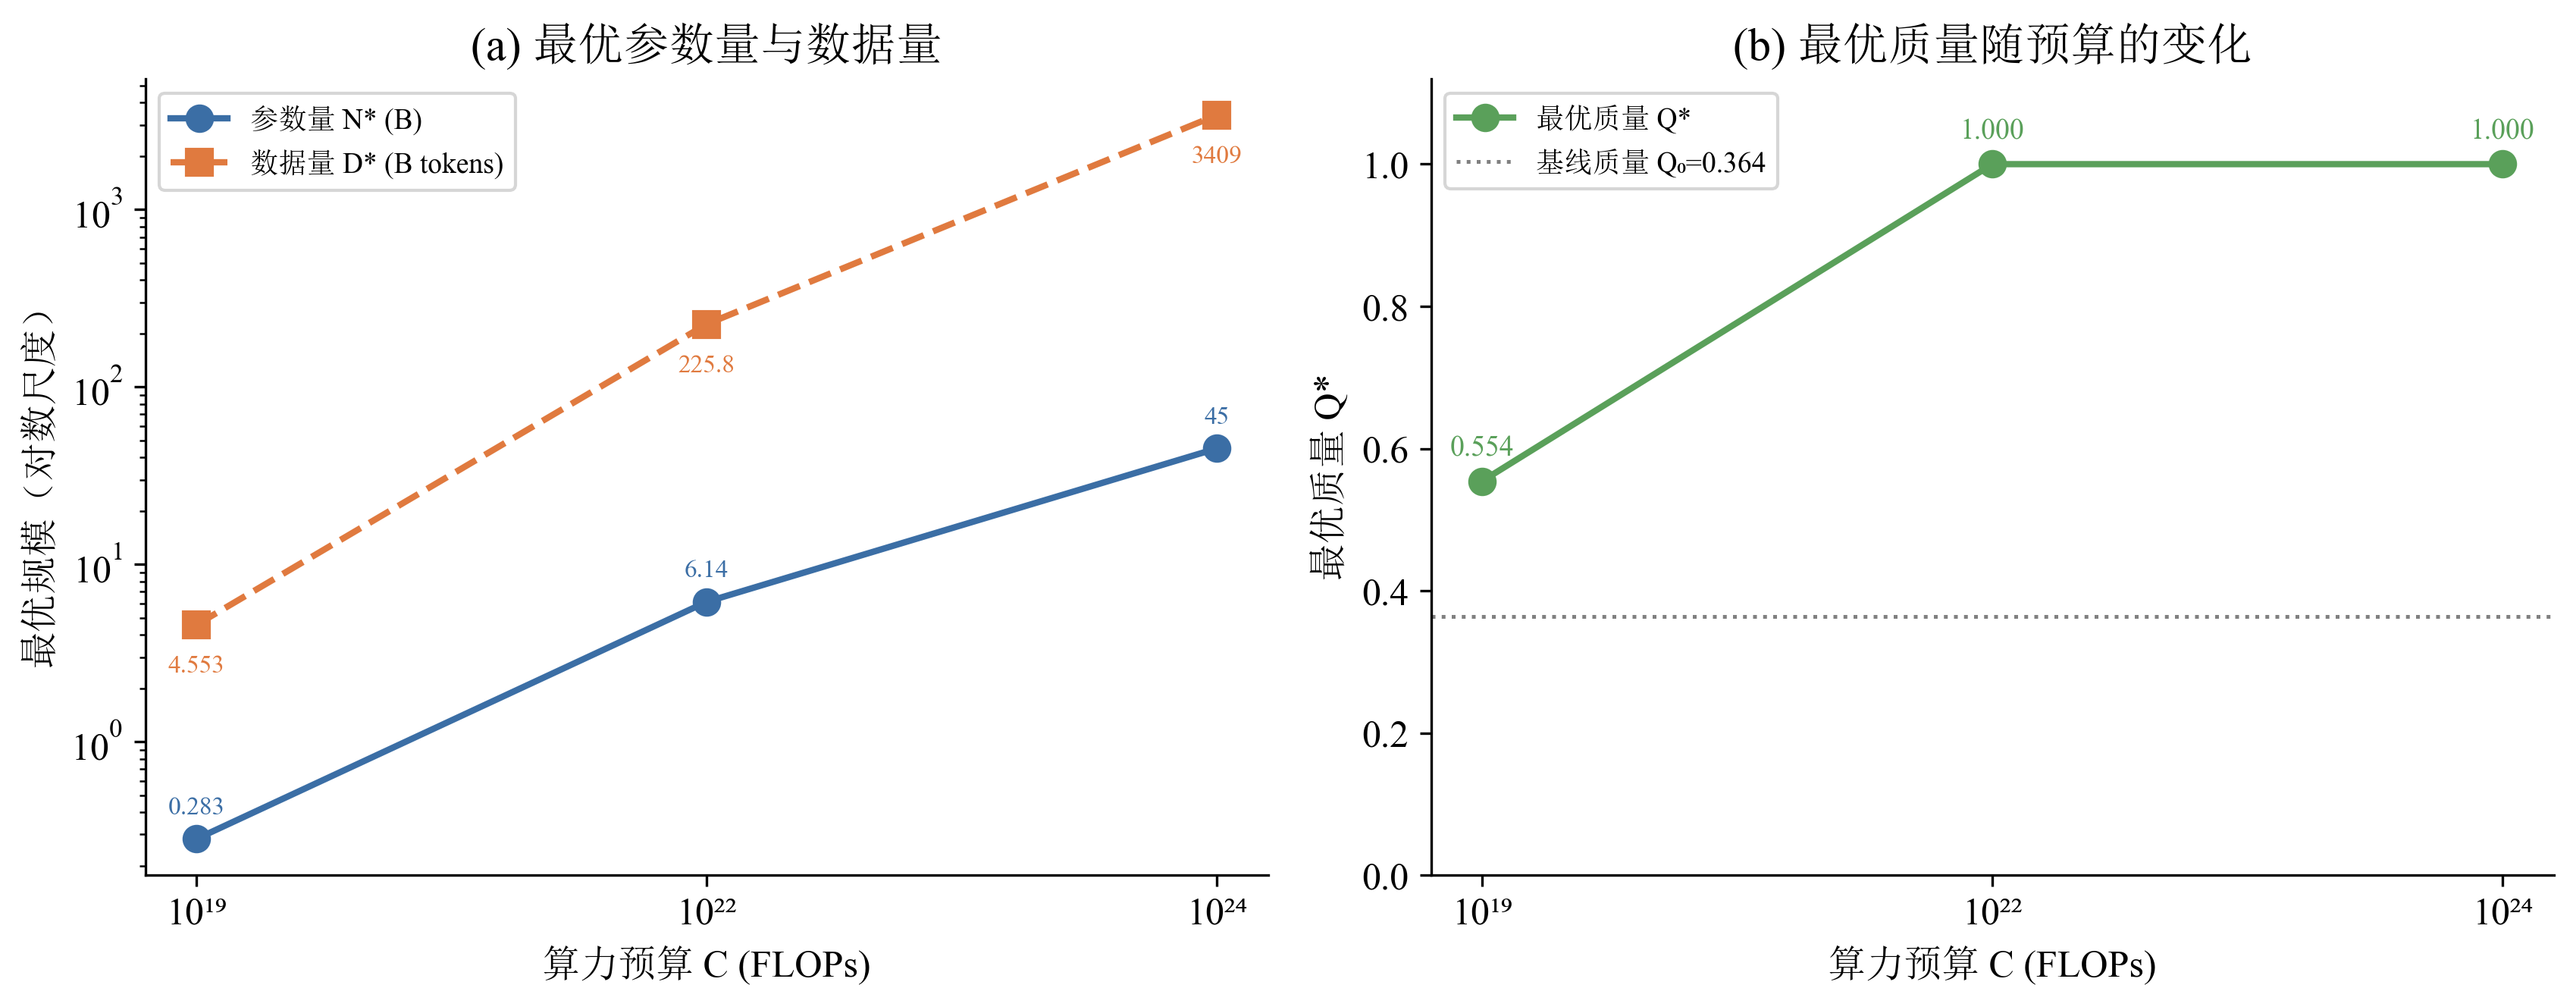

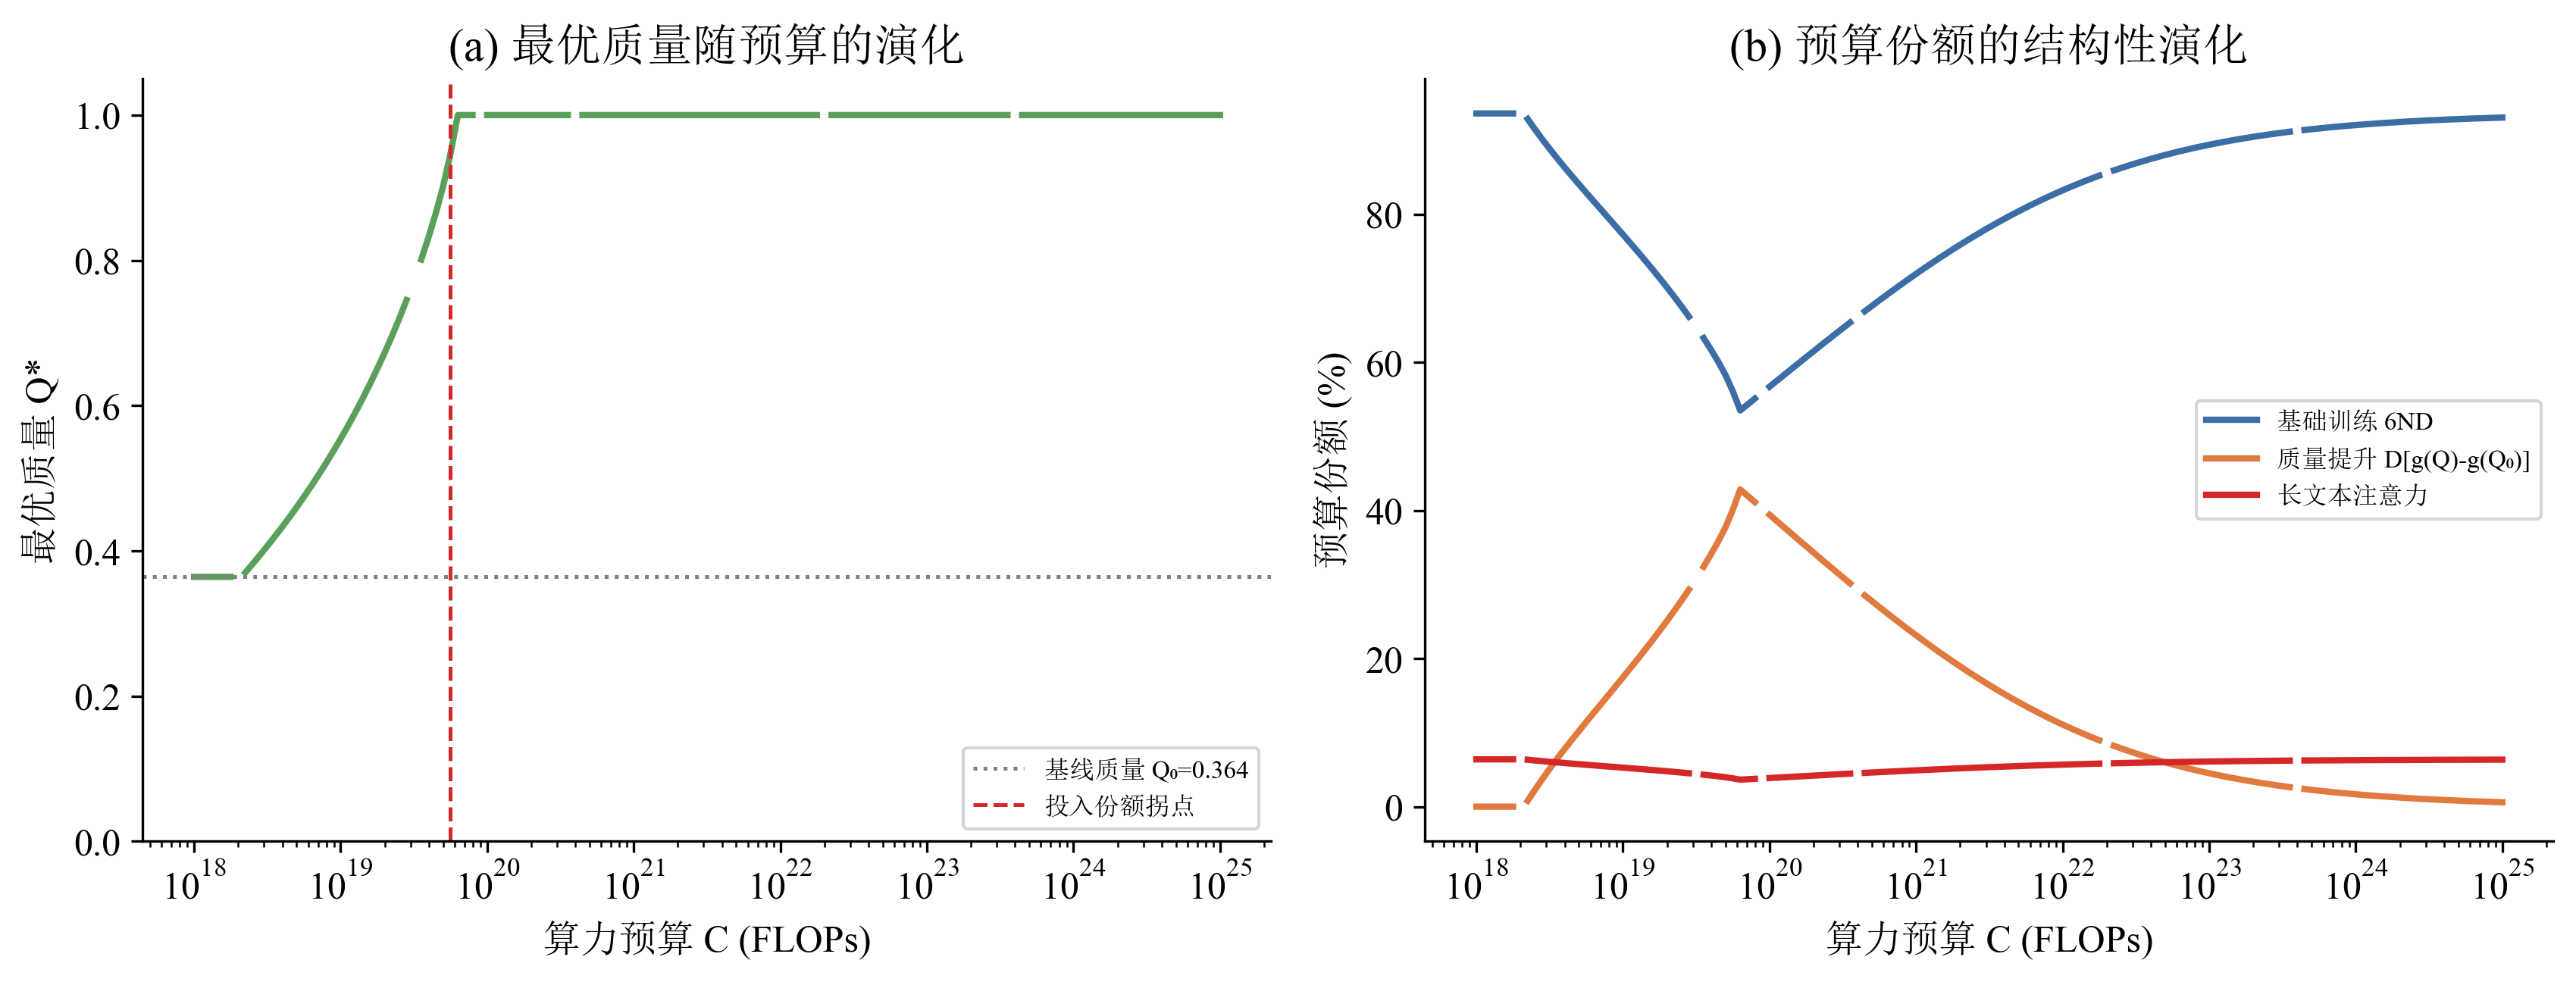

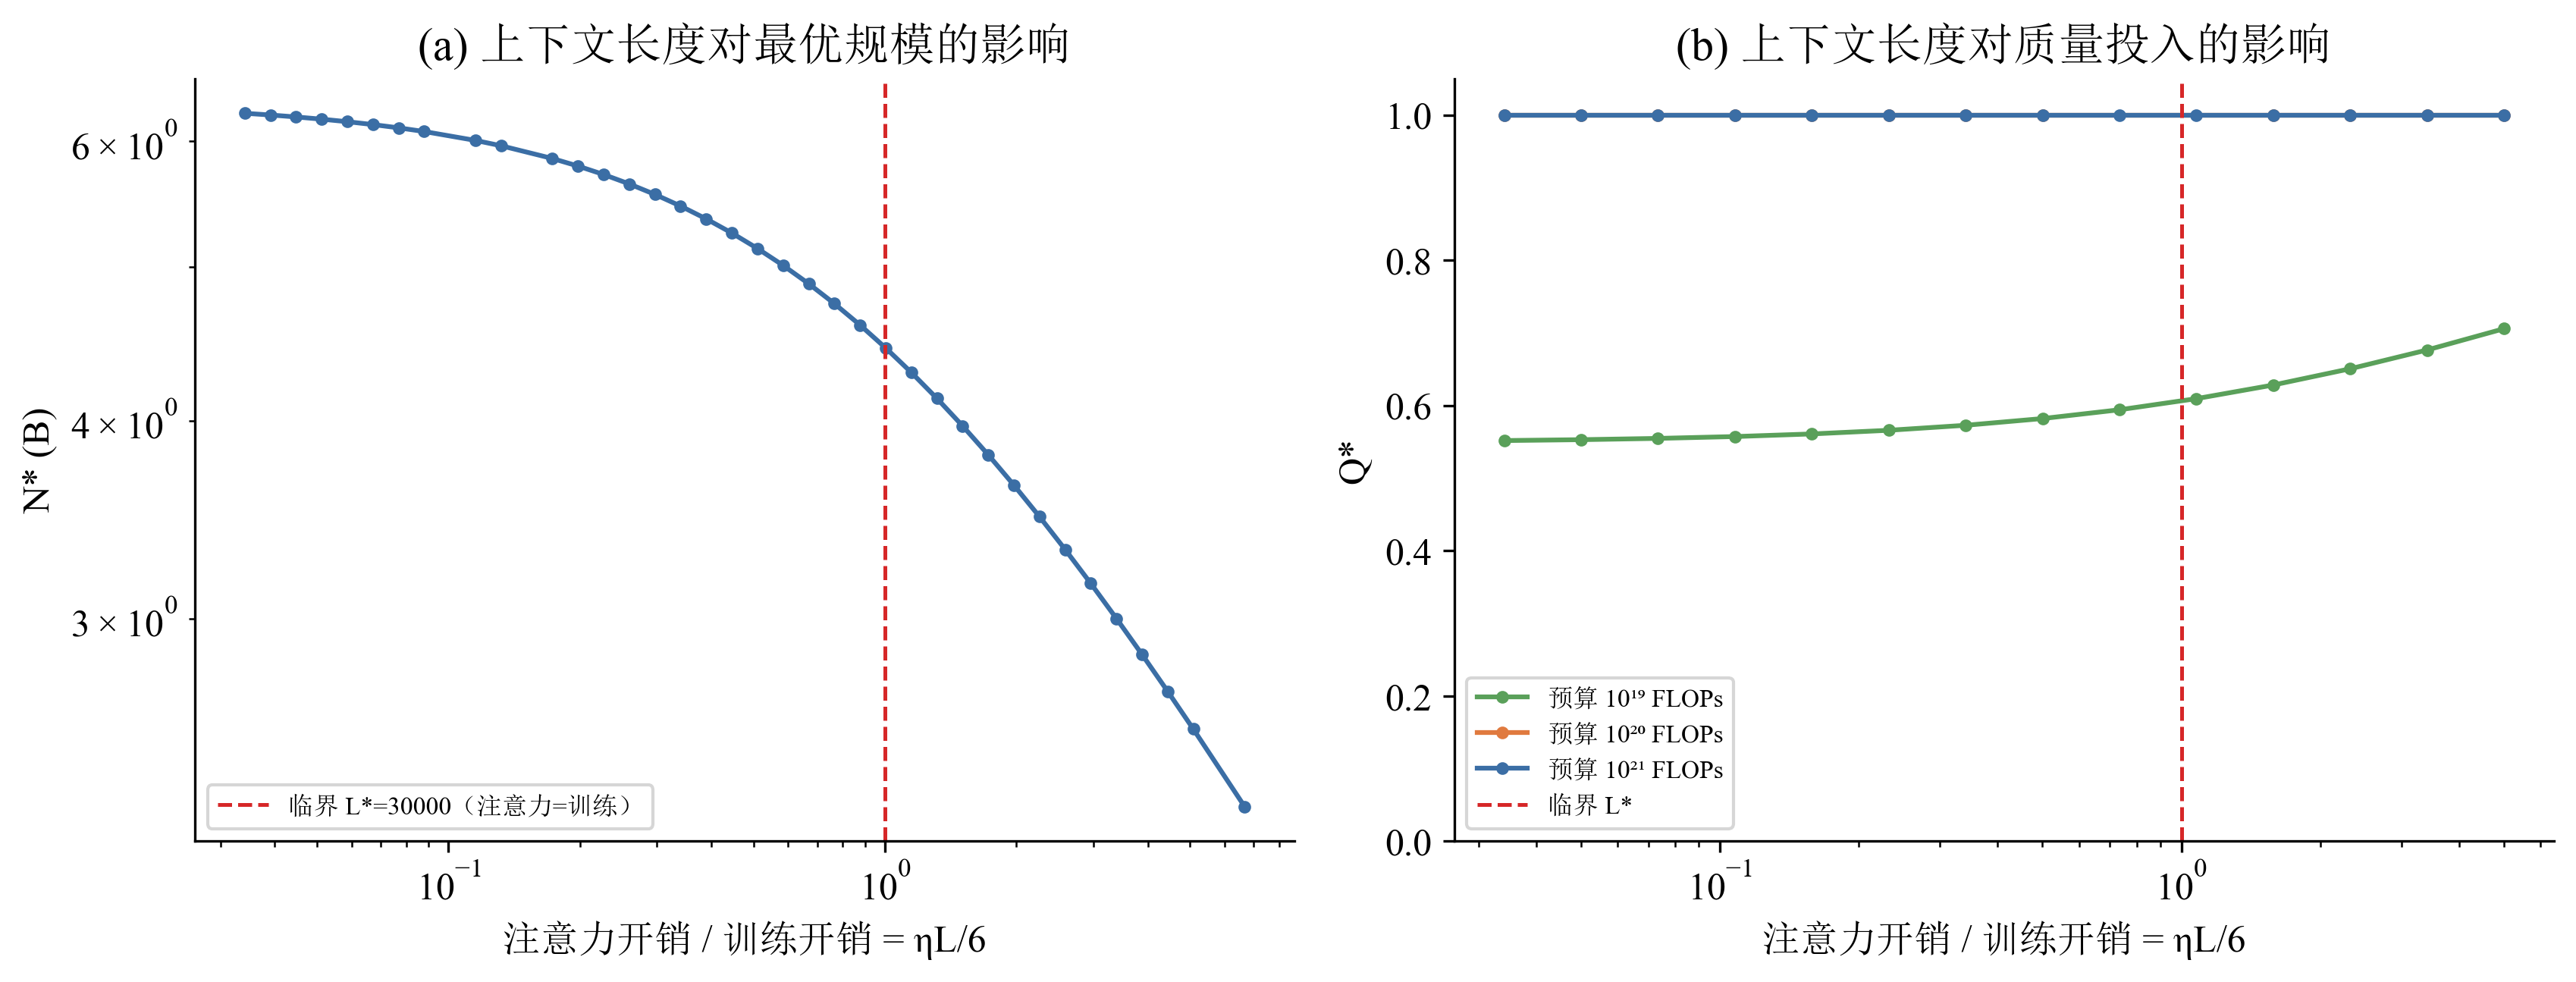

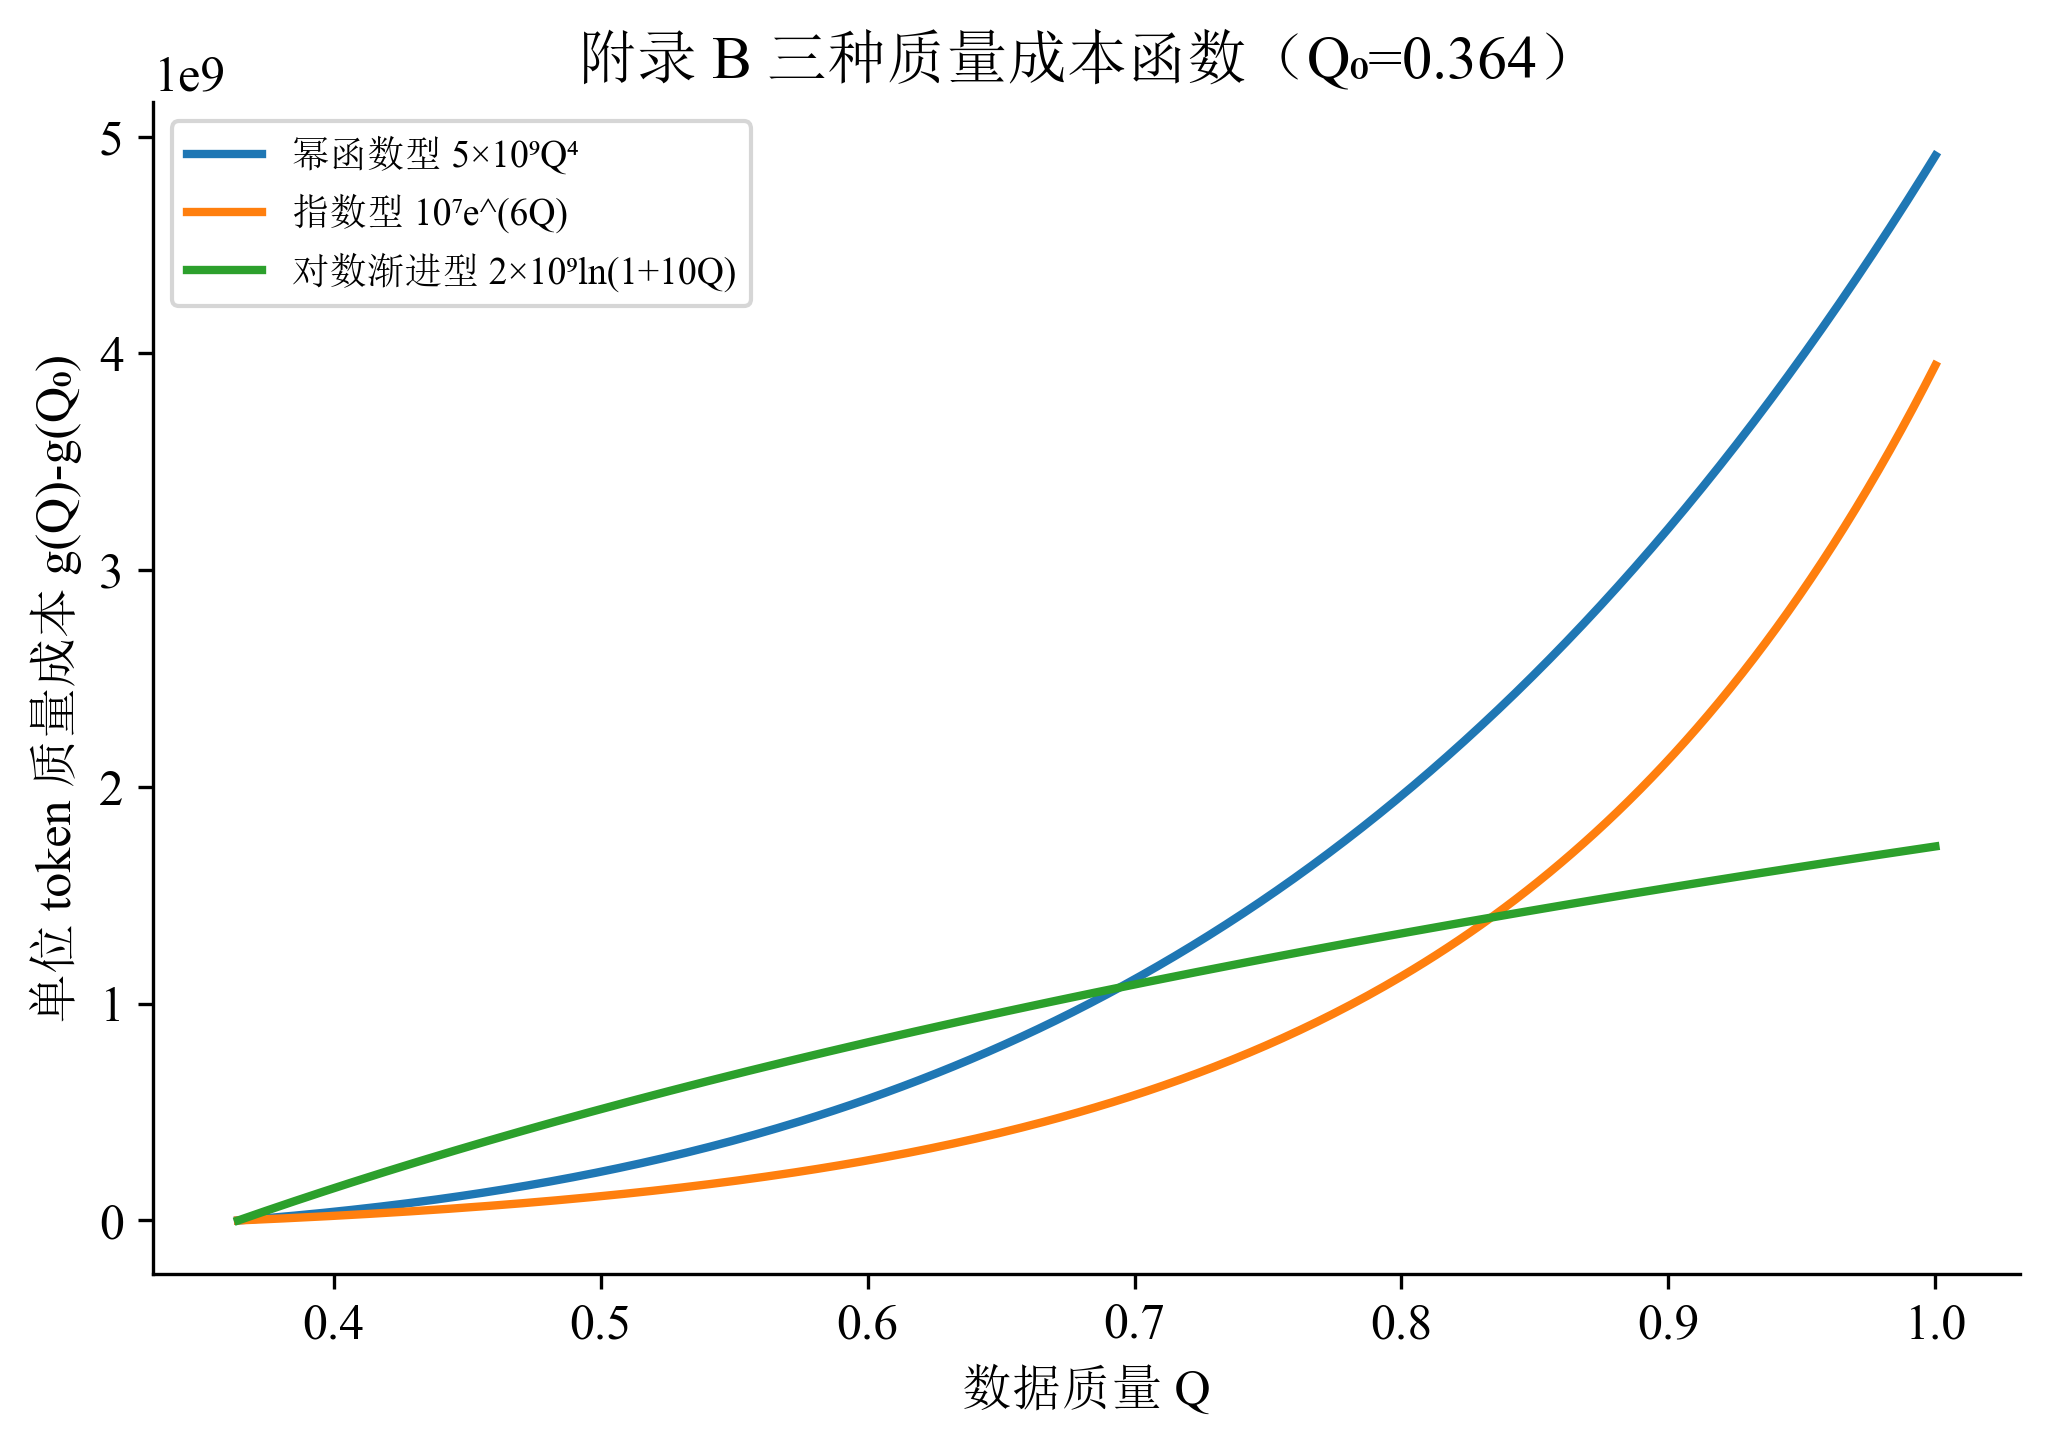

In [12]:
# ============ 8. 绘图 ============
plt.rcParams['font.size'] = 12
C1_, C2_, C3_ = '#3b6ea5', '#e07a3f', '#5aa05a'

opt_df = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
x = np.arange(len(BUDGETS))
axes[0].plot(x, opt_df['N_B'], 'o-', lw=2, ms=8, color=C1_, label='参数量 N* (B)')
axes[0].plot(x, opt_df['D_B'], 's--', lw=2, ms=8, color=C2_, label='数据量 D* (B tokens)')
for xi, (nb, db) in enumerate(zip(opt_df['N_B'], opt_df['D_B'])):
    axes[0].annotate('%.3g' % nb, (xi, nb), fontsize=8, xytext=(0, 8),
                     textcoords='offset points', ha='center', color=C1_)
    axes[0].annotate('%.4g' % db, (xi, db), fontsize=8, xytext=(0, -15),
                     textcoords='offset points', ha='center', color=C2_)
axes[0].set_yscale('log'); axes[0].set_xticks(x)
axes[0].set_xticklabels(['10¹⁹', '10²²', '10²⁴'])
axes[0].set_xlabel('算力预算 C (FLOPs)'); axes[0].set_ylabel('最优规模（对数尺度）')
axes[0].set_title('(a) 最优参数量与数据量'); axes[0].legend(fontsize=9); despine(axes[0])
axes[1].plot(x, opt_df['Q'], 'o-', lw=2, ms=8, color=C3_, label='最优质量 Q*')
axes[1].axhline(Q0, color='gray', ls=':', lw=1.2, label='基线质量 Q₀=%.3f' % Q0)
for xi, qv in enumerate(opt_df['Q']):
    axes[1].annotate('%.3f' % qv, (xi, qv), fontsize=9, xytext=(0, 8),
                     textcoords='offset points', ha='center', color=C3_)
axes[1].set_xticks(x); axes[1].set_xticklabels(['10¹⁹', '10²²', '10²⁴'])
axes[1].set_ylim(0, 1.12); axes[1].set_xlabel('算力预算 C (FLOPs)')
axes[1].set_ylabel('最优质量 Q*'); axes[1].set_title('(b) 最优质量随预算的变化')
axes[1].legend(fontsize=9); despine(axes[1])
fig.tight_layout(); save_fig(fig, '图1_三档预算最优配置')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
axes[0].plot(C_sweep, Qc, lw=2, color=C3_)
axes[0].axhline(Q0, color='gray', ls=':', lw=1.2, label='基线质量 Q₀=%.3f' % Q0)
axes[0].axvline(shift['质量投入份额由升转降的拐点预算'], color='#d62728', ls='--', lw=1.2,
                label='投入份额拐点')
axes[0].set_xscale('log'); axes[0].set_xlabel('算力预算 C (FLOPs)')
axes[0].set_ylabel('最优质量 Q*'); axes[0].set_ylim(0, 1.05)
axes[0].set_title('(a) 最优质量随预算的演化'); axes[0].legend(fontsize=8); despine(axes[0])
axes[1].plot(C_sweep, sw['f_base'] * 100, lw=2, color=C1_, label='基础训练 6ND')
axes[1].plot(C_sweep, sw['f_qual'] * 100, lw=2, color=C2_, label='质量提升 D[g(Q)-g(Q₀)]')
axes[1].plot(C_sweep, sw['f_attn'] * 100, lw=2, color='#d62728', label='长文本注意力')
axes[1].set_xscale('log'); axes[1].set_xlabel('算力预算 C (FLOPs)')
axes[1].set_ylabel('预算份额 (%)'); axes[1].set_title('(b) 预算份额的结构性演化')
axes[1].legend(fontsize=8); despine(axes[1])
fig.tight_layout(); save_fig(fig, '图2_预算份额结构性转移')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
axes[0].plot([r['attn_over_train'] for r in cont], [r['N_B'] for r in cont], 'o-', ms=3, color=C1_)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].axvline(1.0, color='#d62728', ls='--', lw=1.2,
                label='临界 L*=%.0f（注意力=训练）' % L_CRIT)
axes[0].set_xlabel('注意力开销 / 训练开销 = ηL/6'); axes[0].set_ylabel('N* (B)')
axes[0].set_title('(a) 上下文长度对最优规模的影响'); axes[0].legend(fontsize=8); despine(axes[0])
# 右图：不同预算档下 Q* 随注意力开销倍数的变化（低预算档才有内点解，故三档并列）
L_small = np.logspace(np.log10(1024), np.log10(150000), 14)
_qL_rows = []
for Cb, col, lbl in [(1e19, C3_, '10¹⁹'), (1e20, C2_, '10²⁰'), (1e21, C1_, '10²¹')]:
    xs, ys = [], []
    for L in L_small:
        try:
            rr = optimize(Cb, float(L), '幂函数型', n_starts=3)
            xs.append(ETA * L / 6.0); ys.append(rr['Q'])
            _qL_rows.append({'C': Cb, 'L_ctx': float(L), 'attn_over_train': ETA * L / 6.0,
                             'N_B': rr['N_B'], 'D_B': rr['D_B'], 'Q': rr['Q'], 'L': rr['L']})
        except Exception:
            pass
    axes[1].plot(xs, ys, 'o-', ms=3, color=col, label='预算 %s FLOPs' % lbl)
save_csv_safe(pd.DataFrame(_qL_rows), '上下文长度与最优质量.csv')
axes[1].axvline(1.0, color='#d62728', ls='--', lw=1.2, label='临界 L*')
axes[1].set_xscale('log'); axes[1].set_xlabel('注意力开销 / 训练开销 = ηL/6')
axes[1].set_ylabel('Q*'); axes[1].set_ylim(0, 1.05)
axes[1].yaxis.get_major_formatter().set_useOffset(False)
axes[1].set_title('(b) 上下文长度对质量投入的影响')
axes[1].legend(fontsize=8); despine(axes[1])
fig.tight_layout(); save_fig(fig, '图3_上下文长度敏感性')

fig, ax = plt.subplots(figsize=(7, 5))
Q_g = np.linspace(Q0, 1.0, 300)
for form, lbl in [('幂函数型', '幂函数型 5×10⁹Q⁴'),
                  ('指数型', '指数型 10⁷e^(6Q)'),
                  ('对数渐进型', '对数渐进型 2×10⁹ln(1+10Q)')]:
    ax.plot(Q_g, [g_of(q, form) - g_of(Q0, form) for q in Q_g], lw=2, label=lbl)
ax.set_xlabel('数据质量 Q'); ax.set_ylabel('单位 token 质量成本 g(Q)-g(Q₀)')
ax.set_title('附录 B 三种质量成本函数（Q₀=%.3f）' % Q0)
ax.legend(fontsize=9); despine(ax); fig.tight_layout(); save_fig(fig, '图4_质量成本函数对比')


## 第 9 步：汇总

给出临界上下文长度、三档预算最优配置、结构性转移门槛与上下文敏感性的完整结论。

In [13]:
# ============ 9. 汇总 ============
print('\n===== 问题三求解完成 =====')
print('  临界上下文长度 L_crit = 6/eta = %.0f tokens；C7 可行取值 %s' % (L_CRIT, L_FEAS))
print('  三档预算（幂函数型）：' +
      '；'.join('C=%.0e -> N*=%.3fB D*=%.1fB Q*=%.4f L*=%.4f'
                % (r['C'], r['N_B'], r['D_B'], r['Q'], r['L']) for r in rows))



===== 问题三求解完成 =====
  临界上下文长度 L_crit = 6/eta = 30000 tokens；C7 可行取值 [2048, 4096, 8192, 32768, 131072]
  三档预算（幂函数型）：C=1e+19 -> N*=0.283B D*=4.6B Q*=0.5542 L*=3.2147；C=1e+22 -> N*=6.145B D*=225.8B Q*=1.0000 L*=2.1457；C=1e+24 -> N*=45.005B D*=3408.6B Q*=1.0000 L*=1.8975


## 结论解读与本问小结

1. **临界上下文长度** $L_{\text{crit}}=6/\eta=30\,000$ tokens（解析解）。C7 的可行取值 $\{2048,4096,8192,32768,131072\}$ 恰好跨越它：8192 时注意力开销仅为训练开销的 0.273 倍，32768 时已达 1.092 倍。
2. **三档预算**（幂函数型成本、$L_{\text{ctx}}=2048$）：

| 预算 | $N^*$ | $D^*$ | $Q^*$ | $L^*$ | $D^*/N^*$ |
|---|---|---|---|---|---|
| $10^{19}$ | 0.283B | 4.6B | 0.554 | 3.215 | 16.1 |
| $10^{22}$ | 6.145B | 225.8B | 1.000 | 2.146 | 36.7 |
| $10^{24}$ | 45.005B | 3408.6B | 1.000 | 1.898 | 75.7 |

   $D/N$ 比随预算上升，与解析结论 $D^*\propto C^{\alpha/(\alpha+\beta)}$、$\alpha>\beta$ 一致。
3. **成本函数形式只在最低预算档显著影响 $Q^*$**（$0.554\sim1.000$）；中高预算档三型下 $Q^*$ 均顶到上界 1.000，$N^*,D^*$ 差异 $<10\%$ —— 因此"中高预算应把质量做满"是稳健结论。
4. **结构性转移**：两个独立识别量（完成度弹性极值点、质量投入份额拐点）在 $C\approx5.6\times10^{19}$ FLOPs 处一致；$Q^*$ 首次达到 $0.5/0.9/0.99$ 的门槛分别为 $7.1\times10^{18}$、$5.0\times10^{19}$、$6.3\times10^{19}$。含义是：低预算制度"先保规模、质量适度"，中高预算制度"质量饱和后再扩张规模"。
5. **上下文长度挤的是规模、不是质量**：$L_{\text{ctx}}$ 从 2048 增到 131072 时，$N^*$ 被压缩 2.26 倍、$D^*$ 被压缩 2.09 倍、损失上升约 5.9%，但 $Q^*$ 仍为上界。更有意思的是在**低预算档**（$C=10^{19}$），注意力开销上升反而让 $Q^*$ 由 0.552 升到 0.706 —— 因为 $C_Q=D[g(Q)-g(Q_0)]$ 与 $D$ 成正比，长上下文压低了可负担的 $D$，使质量投入相对变便宜。**若把质量成本简化成与 $D$ 无关，这条耦合链会被完全抹掉。**
6. **配比优化的算力等价效果**：推荐配比（$M=-0.1988$）在 $C=10^{22}$ 下把损失由 2.146 降到 1.947；若用参考配比达到同一损失需要 $C\approx2.93\times10^{23}$ FLOPs，即配比调整的效果约等于 29 倍算力扩张（此倍数被损失的算力弹性放大，宜作量级参考）。